# Flow Matching: Inequality Constraints (Barrier Method)

Two examples:
1. Abstract optimization: Minimize $(x-2)^2 + (y-1)^2$ subject to $x + y \geq 1$
2. Reaction equilibrium: Find equilibrium extent for $A + B \rightleftharpoons 2C$

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 14:24:42
Initial memory usage: 320.00 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU for JAX (must be set before importing JAX)
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch
import jax
import jax.numpy as jnp
from jax import jacobian, vmap
from scipy.optimize import minimize, minimize_scalar

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    cluster_stats,
    ConditionalFlowMatching
)

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## 1. Abstract Optimization with Barrier Method

**Problem:** Minimize $(x-2)^2 + (y-1)^2$ subject to $x + y \geq 1$

The barrier objective is:
$$f(x, y) = (x-2)^2 + (y-1)^2 - \mu \log(x + y - 1)$$

At the optimum, the gradient is zero: $\nabla f = 0$.

In [3]:
# Scipy solution
def f_ineq(X):
    x, y = X
    return (x - 2)**2 + (y - 1)**2

def c1(X):
    return X[0] + X[1] - 1

sol = minimize(f_ineq, [1, 1], constraints={'type': 'ineq', 'fun': c1})
print(f"Scipy solution: {sol.x}")

Scipy solution: [2.         0.99999999]


In [4]:
# Barrier objective
def barrier_objective(X, mu=1e-7):
    x, y = X
    obj = (x - 2)**2 + (y - 1)**2
    barrier = -mu * jnp.log(x + y - 1)
    return obj + barrier

# Sample feasible region
bounds = [[0, 3], [0, 3]]
inputs = generate_samples(bounds, n_samples=1024, method='uniform', seed=42)

# Filter to feasible
feasible = inputs[:, 0] + inputs[:, 1] > 1.01
inputs = inputs[feasible]

# Compute gradients
outputs = np.array(vmap(jacobian(barrier_objective))(inputs))

print(f"Feasible samples: {len(inputs)}")

Feasible samples: 950


In [5]:
# Train
fm_barrier = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=64, n_layers=3)
losses = fm_barrier.fit(inputs, outputs, epochs=500, batch_size=64)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [6]:
# Sample by conditioning on gradient = 0
samples = fm_barrier.sample(c_values=[[0.0, 0.0]], n_samples=500)

x_opt = samples.mean(axis=0)
print(f"Flow Matching solution: x={x_opt[0]:.4f}, y={x_opt[1]:.4f}")
print(f"Expected: x=2.0, y=1.0")

Flow Matching solution: x=2.0043, y=1.0096
Expected: x=2.0, y=1.0


---

## 2. Reaction Equilibrium with Barrier Method

A physically motivated example: finding the equilibrium composition of a reversible reaction $A + B \rightleftharpoons 2C$ in a batch reactor using the **barrier method**.

Given initial concentrations $C_{A0} = C_{B0} = 1$ mol/L and $C_{C0} = 0$, the concentrations evolve with extent of reaction $\xi$:
- $C_A = 1 - \xi$
- $C_B = 1 - \xi$
- $C_C = 2\xi$

The equilibrium condition requires:
$$K_{eq} = \frac{C_C^2}{C_A \cdot C_B} = \frac{(2\xi)^2}{(1-\xi)^2}$$

**Optimization formulation:** Minimize the squared equilibrium residual:
$$\min_\xi \quad f(\xi)^2 = \left[K_{eq}(1-\xi)^2 - 4\xi^2\right]^2$$

**Inequality constraints:** Non-negative concentrations require $0 < \xi < 1$

**Barrier method:** We add logarithmic barrier terms to enforce the constraints:
$$\phi(\xi) = f(\xi)^2 - \mu \log(\xi) - \mu \log(1-\xi)$$

At the optimum, $\frac{d\phi}{d\xi} = 0$. We train a Flow Matching model on $[\xi, \frac{d\phi}{d\xi}]$ and condition on the derivative being zero.

In [7]:
# Reaction equilibrium: A + B ⇌ 2C with BARRIER METHOD
from jax import grad

# Parameters
Keq = 1.0  # Equilibrium constant
mu = 0.001  # Barrier parameter

# Analytical solution
# Keq(1-ξ)² = 4ξ² → for Keq=1: (1-ξ)² = 4ξ² → 1-ξ = ±2ξ
# Physical root: ξ = 1/3
xi_analytical = 1/3

print("Reaction Equilibrium: A + B ⇌ 2C")
print(f"Keq = {Keq}")
print(f"Barrier parameter μ = {mu}")
print(f"\nAnalytical solution: ξ = {xi_analytical:.4f}")
print(f"Equilibrium concentrations:")
print(f"  CA = CB = {1 - xi_analytical:.4f} mol/L")
print(f"  CC = {2 * xi_analytical:.4f} mol/L")

# Verify with scipy
def residual_squared(xi):
    f = Keq * (1 - xi)**2 - 4 * xi**2
    return f**2

result_scipy_eq = minimize_scalar(residual_squared, bounds=(0.01, 0.99), method='bounded')
print(f"\nScipy verification (min f²): ξ = {result_scipy_eq.x:.6f}")

Reaction Equilibrium: A + B ⇌ 2C
Keq = 1.0
Barrier parameter μ = 0.001

Analytical solution: ξ = 0.3333
Equilibrium concentrations:
  CA = CB = 0.6667 mol/L
  CC = 0.6667 mol/L

Scipy verification (min f²): ξ = 0.333334


In [8]:
# Define barrier objective function
def barrier_equilibrium(xi):
    """Barrier objective: squared residual + log barriers for 0 < ξ < 1"""
    f = Keq * (1 - xi)**2 - 4 * xi**2
    obj = f**2
    barrier = -mu * jnp.log(xi) - mu * jnp.log(1 - xi)
    return obj + barrier

# Compute gradient of barrier objective
grad_barrier = grad(barrier_equilibrium)

# Generate training data: sample ξ in feasible region (0, 1)
n_eq_samples = 2000
np.random.seed(42)
xi_samples = np.random.uniform(0.02, 0.98, n_eq_samples)

# Compute gradients at each sample point
gradients = np.array([float(grad_barrier(float(xi))) for xi in xi_samples])

# Build training data: x = ξ, c = dφ/dξ
x_data_eq = xi_samples.reshape(-1, 1)
c_data_eq = gradients.reshape(-1, 1)

print(f"Training data shape: x={x_data_eq.shape}, c={c_data_eq.shape}")
print(f"ξ range: [{xi_samples.min():.3f}, {xi_samples.max():.3f}]")
print(f"Gradient range: [{gradients.min():.3f}, {gradients.max():.3f}]")
print(f"\nVerification: dφ/dξ at ξ=1/3: {float(grad_barrier(1/3)):.6f} (should be ≈ 0)")

Training data shape: x=(2000, 1), c=(2000, 1)
ξ range: [0.023, 0.980]
Gradient range: [-4.125, 60.539]

Verification: dφ/dξ at ξ=1/3: -0.001499 (should be ≈ 0)


In [9]:
# Train Flow Matching: generate ξ conditioned on dφ/dξ
fm_eq = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=64, n_layers=3)
losses = fm_eq.fit(x_data_eq, c_data_eq, epochs=500, batch_size=64)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [10]:
# Solve: condition on gradient = 0 (BARRIER METHOD OPTIMIZATION)
xi_fm_samples = fm_eq.sample(c_values=[[0.0]], n_samples=1000, n_steps=100)

# Filter to valid range
xi_fm_samples = xi_fm_samples[(xi_fm_samples[:, 0] > 0) & (xi_fm_samples[:, 0] < 1)]

print("Flow Matching Solution (conditioning on dφ/dξ = 0):")
print(f"  ξ = {xi_fm_samples.mean():.4f} ± {xi_fm_samples.std():.4f}")
print(f"  Analytical: ξ = {xi_analytical:.4f}")

# Verify: check residual at FM solution
def residual_fn(xi):
    return Keq * (1 - xi)**2 - 4 * xi**2

residual_at_fm = residual_fn(xi_fm_samples.mean())
print(f"  |Residual| at FM mean: {abs(residual_at_fm):.6f}")

Flow Matching Solution (conditioning on dφ/dξ = 0):
  ξ = 0.3353 ± 0.0060
  Analytical: ξ = 0.3333
  |Residual| at FM mean: 0.007928


In [11]:
# Summary comparison
print("Reaction Equilibrium with Barrier Method: A + B ⇌ 2C")
print("=" * 65)
print(f"Equilibrium constant: Keq = {Keq}")
print(f"Barrier parameter: μ = {mu}")
print()

print(f"{'Method':<25} {'ξ':<15} {'|Residual|':<15}")
print("-" * 55)

# Analytical
print(f"{'Analytical':<25} {xi_analytical:<15.6f} {abs(residual_fn(xi_analytical)):<15.6f}")

# Scipy
print(f"{'Scipy (bounded)':<25} {result_scipy_eq.x:<15.6f} {abs(residual_fn(result_scipy_eq.x)):<15.6f}")

# Flow Matching with barrier method
xi_fm_mean = float(xi_fm_samples.mean())
print(f"{'FM (barrier method)':<25} {xi_fm_mean:<15.6f} {abs(residual_fn(xi_fm_mean)):<15.6f}")

Reaction Equilibrium with Barrier Method: A + B ⇌ 2C
Equilibrium constant: Keq = 1.0
Barrier parameter: μ = 0.001

Method                    ξ               |Residual|     
-------------------------------------------------------
Analytical                0.333333        0.000000       
Scipy (bounded)           0.333334        0.000004       
FM (barrier method)       0.335312        0.007928       


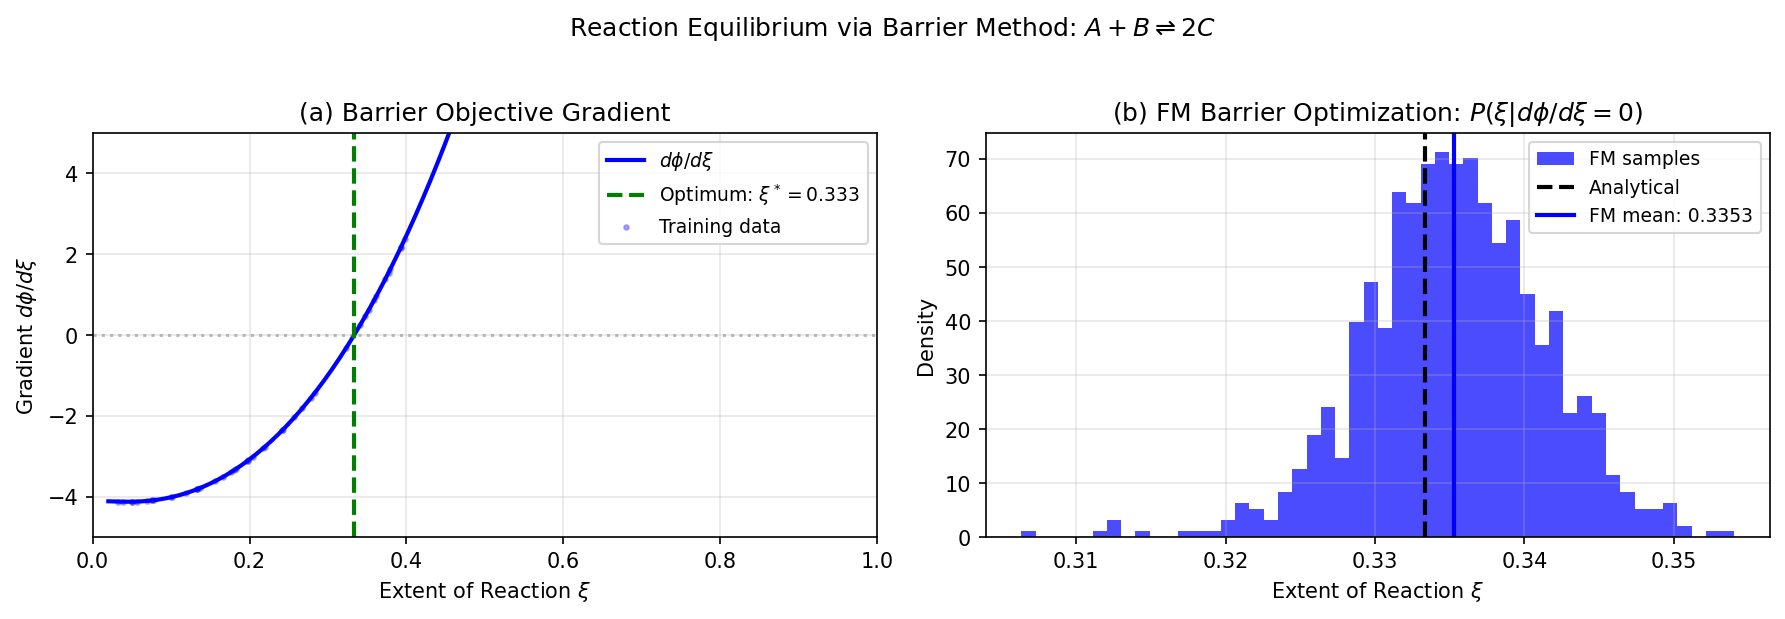

In [12]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Barrier objective gradient
xi_plot = np.linspace(0.02, 0.98, 200)
grad_plot = np.array([float(grad_barrier(xi)) for xi in xi_plot])

ax1.plot(xi_plot, grad_plot, 'b-', lw=2, label='$d\\phi/d\\xi$')
ax1.axhline(0, color='gray', ls=':', alpha=0.5)
ax1.axvline(xi_analytical, color='green', ls='--', lw=2, label=f'Optimum: $\\xi^*={xi_analytical:.3f}$')
ax1.scatter(xi_samples[::20], gradients[::20], s=5, alpha=0.3, c='blue', label='Training data')

ax1.set_xlabel('Extent of Reaction $\\xi$')
ax1.set_ylabel('Gradient $d\\phi/d\\xi$')
ax1.set_title('(a) Barrier Objective Gradient')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(-5, 5)

# Right: Flow Matching histogram
ax2.hist(xi_fm_samples[:, 0], bins=50, alpha=0.7, color='blue', 
         label='FM samples', density=True)
ax2.axvline(xi_analytical, color='black', ls='--', lw=2, label='Analytical')
ax2.axvline(xi_fm_samples.mean(), color='blue', ls='-', lw=2, 
            label=f'FM mean: {xi_fm_samples.mean():.4f}')

ax2.set_xlabel('Extent of Reaction $\\xi$')
ax2.set_ylabel('Density')
ax2.set_title('(b) FM Barrier Optimization: $P(\\xi | d\\phi/d\\xi = 0)$')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Reaction Equilibrium via Barrier Method: $A + B \\rightleftharpoons 2C$', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 14:24:42
End time:        2025-12-18 14:25:01
Elapsed time:    18.60 seconds (0.31 minutes)
----------------------------------------------------------------------
Initial memory:  320.00 MB
Final memory:    607.19 MB
Memory change:   +287.19 MB
